# P2.7 · Attention as a weighted mixture

**Maths fundamentals for transformers · Tiny Transformer**

A token’s initial vector contains no information from other tokens. Attention supplies a learned way to combine earlier information.

**You will be able to:** Attention scores allowed positions, turns scores into shares, and sums the value vectors weighted by those shares.

This notebook runs independently in Jupyter or Google Colab on a CPU. Download it from the course, then use **Colab → File → Upload notebook**. Public publication target: https://github.com/gkiri/tiny_repo. All required numerical examples are included.

The model connection uses the same **9,417-parameter transformer** as Unit 1: 65 characters, 32 positions, 28 features, two heads, learned position embeddings, LayerNorm and GELU.

In [1]:
#@title Setup: CPU, local Jupyter or Google Colab { display-mode: "form" }
# This notebook is self-contained. No account, secret, repository clone or GPU is required.
import sys, math, json, base64, zlib, hashlib
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(7)
torch.set_num_threads(1)
plt.rcParams.update({"figure.figsize": (7, 3), "figure.dpi": 100, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.alpha": .18})
print("Ready on CPU · PyTorch", torch.__version__)
print("All example data is included in this notebook.")

Ready on CPU · PyTorch 2.10.0+cpu
All example data is included in this notebook.


## Predict first

How does one position gather information?

Write down your prediction before running the calculation.

Mix value vectors [2, 0] and [0, 2] with shares 0.75 and 0.25.

## Work the numbers

1. Query · keys → scores

2. Divide by √d; hide future positions

3. Softmax → shares summing to 1

4. Mix: 0.75[2,0] + 0.25[0,2] = [1.5,0.5]

$$A=\operatorname{softmax}(QK^{\mathsf T}/\sqrt{d_h}+M),\quad Y=AV$$

These small numbers are **Illustrative**. Each symbol names a quantity already shown above.

In [2]:
#@title Explicit teaching functions (expand to inspect) { display-mode: "form" }
"""P2's explicit calculations. Each function is checked against an independent PyTorch operation.

Rows use the final axis for features. Linear weights use PyTorch's [out, in] convention.
These readable implementations teach the operations; the reference model remains unchanged.
"""
import math
import torch


def dot(x, y):
    if x.shape != y.shape or x.ndim != 1:
        raise ValueError("dot needs two vectors of the same length")
    return (x * y).sum()


def linear(x, weight, bias):
    return x @ weight.transpose(-2, -1) + bias


def embeddings(ids, token_table, position_table):
    positions = torch.arange(ids.shape[-1], device=ids.device)
    if ids.shape[-1] > position_table.shape[0]:
        raise ValueError("the position table is shorter than the input")
    return token_table[ids] + position_table[positions]


def layernorm(x, gamma, beta, eps=1e-5):
    mean = x.mean(dim=-1, keepdim=True)
    variance = ((x - mean) ** 2).mean(dim=-1, keepdim=True)
    return (x - mean) / torch.sqrt(variance + eps) * gamma + beta


def softmax(scores, temperature=1.0):
    if temperature <= 0 or not math.isfinite(temperature):
        raise ValueError("temperature must be finite and positive")
    if torch.isnan(scores).any() or torch.isposinf(scores).any() or torch.isneginf(scores).all(dim=-1).any():
        raise ValueError("each score row needs a finite entry, with no NaN or positive infinity")
    scaled = scores / temperature
    shifted = scaled - scaled.max(dim=-1, keepdim=True).values
    positive = torch.exp(shifted)
    return positive / positive.sum(dim=-1, keepdim=True)


def attention(q, k, v):
    scores = q @ k.transpose(-2, -1) / math.sqrt(q.shape[-1])
    allowed = torch.ones(scores.shape[-2:], dtype=torch.bool, device=q.device).tril()
    masked = scores.masked_fill(~allowed, float("-inf"))
    shares = softmax(masked)
    return shares @ v, shares, masked


def gelu(x):
    cdf = 0.5 * (1 + torch.erf(x / math.sqrt(2)))
    return x * cdf


def residual(x, update):
    if x.shape != update.shape:
        raise ValueError("a residual update must have the same shape as its input")
    return x + update


def cross_entropy(logits, targets):
    log_prob = logits - torch.logsumexp(logits, dim=-1, keepdim=True)
    correct = log_prob.gather(-1, targets.unsqueeze(-1)).squeeze(-1)
    return -correct.mean()


def tiny_loss(w):
    """One adjustable logit: target 0, logits [2*w, 1, 0]."""
    z = torch.stack((2 * w, torch.ones_like(w), torch.zeros_like(w)))
    return cross_entropy(z.unsqueeze(0), torch.tensor([0], device=w.device))


def finite_difference(f, x, step=1e-5):
    return (f(x + step) - f(x - step)) / (2 * step)


def adamw_step(parameter, gradient, first, second, step, lr=0.003,
               betas=(0.9, 0.999), eps=1e-8, weight_decay=0.01):
    """One AdamW update, including moment bias correction and decoupled weight decay."""
    beta1, beta2 = betas
    first = beta1 * first + (1 - beta1) * gradient
    second = beta2 * second + (1 - beta2) * gradient.square()
    first_hat = first / (1 - beta1 ** step)
    second_hat = second / (1 - beta2 ** step)
    parameter = parameter * (1 - lr * weight_decay) - lr * first_hat / (second_hat.sqrt() + eps)
    return parameter, first, second

print("Explicit functions loaded; each is independently tested against PyTorch.")

Explicit functions loaded; each is independently tested against PyTorch.


## Implement and verify

Read each line, predict its output, then run it. The explicit calculation and the PyTorch operation should agree.

In [3]:
q = torch.tensor([[1., 0.], [0., 1.], [1., 1.]])
k = torch.tensor([[1., 0.], [0., 1.], [1., -1.]])
v = torch.tensor([[2., 0.], [0., 2.], [1., 1.]])
scores = q @ k.T / math.sqrt(q.shape[-1])
allowed = torch.ones(3, 3, dtype=torch.bool).tril()
shares = torch.softmax(scores.masked_fill(~allowed, float('-inf')), dim=-1)
y = shares @ v
print("shares", shares.tolist())
print("mixtures", y.tolist())
torch.testing.assert_close(y, F.scaled_dot_product_attention(q, k, v, is_causal=True))
assert shares.triu(1).count_nonzero() == 0

shares [[1.0, 0.0, 0.0], [0.3302384614944458, 0.6697615385055542, 0.0], [0.40111207962036133, 0.40111207962036133, 0.19777581095695496]]
mixtures [[2.0, 0.0], [0.6604769229888916, 1.3395230770111084], [1.0, 1.0]]


## See it and change one thing

The plot is generated by the code. Change one input and predict how the picture will change before running it again.

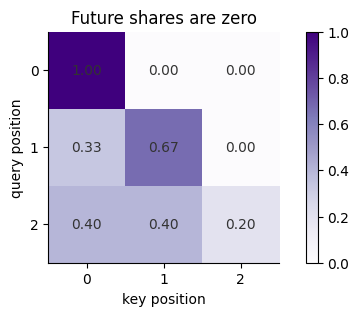

Changing a future value leaves earlier outputs unchanged.


In [4]:
q=torch.tensor([[1.,0.],[0.,1.],[1.,1.]])
k=torch.tensor([[1.,0.],[0.,1.],[1.,-1.]])
v=torch.tensor([[2.,0.],[0.,2.],[1.,1.]])
y,shares,_=attention(q,k,v)
plt.imshow(shares.numpy(),vmin=0,vmax=1,cmap="Purples")
for i in range(3):
    for j in range(3): plt.text(j,i,f"{shares[i,j]:.2f}",ha="center",va="center",color="#333")
plt.xticks(range(3));plt.yticks(range(3));plt.xlabel("key position");plt.ylabel("query position");plt.title("Future shares are zero");plt.grid(False);plt.colorbar();plt.show()
changed=v.clone();changed[-1]+=100
torch.testing.assert_close(attention(q,k,changed)[0][:-1],y[:-1])
print("Changing a future value leaves earlier outputs unchanged.")

## Find it in the transformer

The following values were exported at full precision from the pinned Unit 1 checkpoint. Crops are for display; complete vectors are used in calculations.

Recorded input: `You taught me language; and my p`.

Reference lesson: **inside-attention**.

In [5]:
#@title Recorded model fixture (included; no download) { display-mode: "form" }
recorded = json.loads('{"shares":[[[1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[0.37628644704818726,0.6237135529518127,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[0.5465314388275146,0.27437490224838257,0.17909371852874756,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[0.31368288397789,0.053451262414455414,0.274702250957489,0.35816365480422974,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[0.0023468038998544216,0.00210079038515687,0.004640574101358652,0.9816743731498718,0.00923735462129116,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[0.008258362300693989,0.007327388972043991,0.0765186995267868,0.41913214325904846,0.27310460805892944,0.2156587839126587,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[0.004466479178518057,0.002356982324272394,0.0017615951364859939,0.15682049095630646,0.004107205662876368,0.468524307012558,0.3619629442691803,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[5.7732682762434706e-05,5.2698792387673166e-06,0.00021981896134093404,0.013387673534452915,0.0005488034803420305,0.173141747713089,0.6970695853233337,0.11556937545537949,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[0.0002490090555511415,3.869598367600702e-05,0.0015680283540859818,0.008688481524586678,0.0032679676078259945,0.08256076276302338,0.3606511652469635,0.0053709400817751884,0.5376049876213074,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[3.4014098559964623e-07,3.224791100819857e-07,7.833705808479863e-07,0.00022536548203788698,2.128082087438088e-06,0.0016481464263051748,0.0006856005638837814,0.004746741149574518,0.9847762584686279,0.007914310321211815,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[0.0013810646487399936,0.0002480541879776865,0.0015226769028231502,0.002756191650405526,0.005882562138140202,0.0036747732665389776,0.027674918994307518,0.02894018031656742,0.40027427673339844,0.19282399117946625,0.33482128381729126,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[1.169236583109523e-07,1.411901973114027e-08,7.505688586206816e-07,4.918758349958807e-06,1.8192622519563884e-06,5.615034024231136e-05,0.0009809692855924368,2.462542943248991e-05,0.029846403747797012,0.011159989051520824,0.8382238149642944,0.11970038712024689,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[7.807047452956795e-09,8.66400906573972e-09,4.119429419802145e-08,3.6335432014311664e-06,6.154765941346341e-08,1.4104814908932894e-05,6.119051249697804e-05,0.00010338497668271884,0.002524167997762561,0.00040253985207527876,0.790736734867096,0.15415546298027039,0.051998697221279144,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[0.00015745576820336282,2.897238482546527e-05,0.0001812849222915247,0.00036063953302800655,0.0007963592652231455,0.000520304951351136,0.003911982756108046,0.00429693516343832,0.06551169604063034,0.03223742917180061,0.058622732758522034,0.1958702802658081,0.16462227702140808,0.47288161516189575,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[4.357710373104062e-11,5.087086307753452e-11,1.756059186952541e-11,3.75258180085325e-09,9.179410009885203e-11,5.0461295586501365e-08,5.486451115643831e-08,1.548764885228593e-06,5.571264409809373e-05,1.6295732621074421e-06,0.0030931083019822836,0.024776235222816467,0.053594738245010376,0.8077359199523926,0.11074093729257584,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[3.1007928669168905e-08,3.066404019591573e-08,3.611734200603678e-07,2.6901338969764765e-06,2.1352022940845927e-06,1.8303892375115538e-06,6.148568354547024e-05,8.476361108478159e-05,0.0005166473565623164,0.001042398507706821,0.014392348006367683,0.01208293903619051,0.0012160008773207664,0.4644986689090729,0.25419488549232483,0.25190266966819763,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[4.1232239112809835e-14,1.9258156335366823e-14,1.606308835944148e-12,3.483058980124909e-11,5.2963089643143224e-12,6.462907431448173e-10,1.1730194593440046e-08,3.900073153317862e-08,2.5003639620990725e-06,2.6348840265200124e-07,0.00011493269994389266,0.0007085539982654154,0.0008623307221569121,0.05509563907980919,0.01805582456290722,0.8617261648178101,0.0634336844086647,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[1.1194686941762982e-13,1.1047853272136681e-14,4.868671112968903e-13,3.951409685565288e-11,1.8710074722178005e-12,6.514502826071578e-10,2.6409239239910676e-09,5.322705054489063e-10,6.609274691982137e-07,6.706665089950548e-08,8.445752609986812e-05,1.0253475011268165e-05,0.0017733346903696656,0.03504841402173042,0.0023555054794996977,0.5183061361312866,0.08367476612329483,0.3587464690208435,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[1.6822281068140654e-10,9.85332856973109e-11,7.472734236957379e-11,9.304093495643428e-09,2.9472990714651814e-10,3.654408686770694e-08,2.8302979515615334e-08,1.411406174156582e-07,1.3986627891426906e-06,3.7536378272307047e-07,0.00020045918063260615,5.381547089200467e-05,3.466416455921717e-05,0.011676267720758915,0.008658957667648792,0.03885512053966522,0.26363450288772583,0.12968775629997253,0.5471964478492737,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[1.8118172240289e-10,1.8377710464534402e-10,2.0176740278543548e-09,1.6080601739076883e-08,1.3303245616214099e-08,1.1118797438314232e-08,3.6327975294625503e-07,5.326372729541617e-07,3.2603013551124604e-06,6.954818218218861e-06,9.449757635593414e-05,8.007844007806852e-05,8.091524250630755e-06,0.0031682802364230156,0.0017860012594610453,0.0017433777684345841,0.02616802044212818,0.07388152927160263,0.7072420716285706,0.1858168989419937,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[5.1814176671292927e-17,5.078213154515134e-18,2.090410609979017e-16,1.7608615574763592e-14,8.430254755621626e-16,2.9409021875745345e-13,1.1523556631490295e-12,2.3629912588273017e-13,3.014147542668155e-10,3.083418242955105e-11,3.8673679370049285e-08,4.663128105875103e-09,8.384191119148454e-07,1.6226871593971737e-05,1.1012468803528463e-06,0.00024315821065101773,4.004035872640088e-05,0.0001654856896493584,0.07617789506912231,0.851353645324707,0.0720016211271286,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[4.438314153725658e-15,5.15270004737404e-15,2.2158159977540316e-14,2.2347098130315324e-12,4.2490042381901e-14,9.289489316666177e-12,3.9162690451677307e-11,7.519174866077449e-11,1.937091376191802e-09,3.4425373662827496e-10,6.522121793750557e-07,1.3755739303178416e-07,4.7837907857228856e-08,0.00010881338675972074,4.775822617375525e-06,0.0003613878507167101,0.00032852470758371055,0.002391635673120618,0.05799270421266556,0.3396892547607422,0.3865232765674591,0.21259886026382446,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[0.010217823088169098,0.005606058984994888,0.01895952969789505,0.00687297573313117,0.038601141422986984,0.0006407010951079428,0.02164609357714653,0.07049709558486938,0.044586680829524994,0.036707356572151184,0.006573251448571682,0.010282672941684723,0.0009648982668295503,0.006090431474149227,0.0001377301523461938,0.0004602578410413116,0.0029802359640598297,0.04917452111840248,0.013954372145235538,0.0003749106836039573,0.041286651045084,0.000567112467251718,0.6128174662590027,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[1.0281143048018748e-08,1.9433146203340357e-09,1.0561815422249765e-08,2.3610745358837448e-08,5.8293327498404324e-08,3.5134174680706565e-08,2.5396727210136305e-07,3.18010279443115e-07,4.751849701278843e-06,2.6985285330738407e-06,4.6084410314506385e-06,1.6295720342895947e-05,1.4058215128898155e-05,4.00680692109745e-05,4.569266820908524e-05,5.285748193273321e-05,0.0004698268021456897,0.00044192688073962927,0.001800135592930019,0.0009209879208356142,0.003689304692670703,0.008204078301787376,0.9338477849960327,0.05044429749250412,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[3.660491777312397e-13,3.6553079356752005e-13,3.730811232866005e-12,3.171558154990706e-11,2.6332490007940912e-11,2.1639620650937275e-11,6.819509401623236e-10,1.0468319544543192e-09,6.48563958094428e-09,1.4042139895309447e-08,1.9155852726271405e-07,1.6014276127407356e-07,1.6770249189335118e-08,6.499122264358448e-06,3.6314122553449124e-06,3.531938091327902e-06,5.4799260396976024e-05,0.00015136406000237912,0.0013960138894617558,0.00038319858140312135,0.004887688439339399,0.0005892141489312053,0.03437378630042076,0.8182434439659119,0.13990648090839386,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[2.3912898392145575e-22,1.1294618877963877e-22,8.124796582075284e-21,1.9323297123347597e-19,3.1577161057465806e-20,3.484014843311592e-18,6.008690923910926e-17,2.1983155929676204e-16,1.3959771279746253e-14,1.5976157351124112e-15,6.51737398858071e-13,4.005731510381416e-12,4.962501763683402e-12,3.152220429125663e-10,1.045760075757407e-10,4.7892410037775335e-09,3.966444395153701e-10,2.5366645672875165e-07,6.9573320615745615e-06,1.9164192053722218e-05,0.00011907269799849018,0.0005647119251079857,0.0002610107185319066,0.31954994797706604,0.6344097852706909,0.04506915807723999,0.0,0.0,0.0,0.0,0.0,0.0],[2.3346521707694247e-20,1.6377096916344508e-19,5.3972800846291415e-19,4.96080727427242e-17,2.181024019191271e-18,6.697741506241561e-16,1.3728987412387926e-15,7.665396773272673e-14,8.067743521855686e-13,2.74238249974414e-14,2.6085959781152468e-11,1.3529587172822488e-10,7.728495621250886e-10,5.659535062818577e-09,3.141735482881103e-10,6.023110188380087e-08,1.2145888739212296e-08,5.477817012433661e-06,5.09313531438238e-06,7.387933146674186e-05,0.0010620929533615708,0.0065525854006409645,0.0011804234236478806,0.30335697531700134,0.5608482360839844,0.10008194297552109,0.02683323062956333,0.0,0.0,0.0,0.0,0.0],[5.521838986055627e-09,1.0322210863833448e-09,5.298220973060097e-09,1.2167066465451626e-08,3.0036510167974484e-08,1.755667078384704e-08,1.237478812754489e-07,1.548350923030739e-07,2.3118584522308083e-06,1.3419088418231695e-06,2.26073734665988e-06,7.433960035996279e-06,6.6417051129974425e-06,1.9255596271250397e-05,2.139187381544616e-05,2.46483032242395e-05,0.00021959033620078117,0.00020111296907998621,0.0008075160440057516,0.000418454670580104,0.0016476234886795282,0.0036581954918801785,0.3975624740123749,0.02275032550096512,0.014413761906325817,0.11953184008598328,0.07260395586490631,0.36609944701194763,0.0,0.0,0.0,0.0],[4.149336346666029e-20,5.15017876284252e-21,2.172820196972335e-19,1.7763635412175734e-18,7.547694802240771e-19,2.055703964360864e-17,3.2756471371108104e-16,1.0233621285335554e-17,1.2499043480448425e-14,5.529632673517519e-15,3.8595881590546e-13,5.752719128967673e-14,3.834114883222162e-12,5.87807372220972e-11,2.232065574037101e-11,5.755804166618361e-10,5.989060636313326e-11,2.3606280818988523e-10,3.3999057791334053e-07,4.821174570679432e-07,3.4155291928072984e-08,1.3056654097454157e-05,3.2523879781365395e-05,0.0012173447757959366,0.002171772997826338,0.00020134971418883651,0.0004786720674019307,0.8527977466583252,0.14308661222457886,0.0,0.0,0.0],[1.3672400894126154e-22,1.0261706622990576e-21,5.925358391537589e-20,9.49847361491579e-19,1.0737141427037915e-18,7.250110683212954e-18,8.48025299291568e-17,1.578823488614407e-16,1.3593764955105881e-15,7.151619452346568e-15,1.9564439044522652e-13,3.031841813196101e-13,2.2182515562905666e-14,2.8866841209063132e-11,9.370922440798957e-12,1.7767708138105576e-10,1.212322742194516e-10,3.1188369664647553e-09,7.219740894015558e-08,1.396755067162303e-07,4.4274423771639704e-07,6.421571896453315e-08,7.177698535087984e-06,0.0004851188277825713,0.0005880808457732201,0.00035244677565060556,0.001246585394255817,0.3359549641609192,0.5652281045913696,0.09613675624132156,0.0,0.0],[8.422621489145854e-10,1.5774014039404705e-10,7.912773214435731e-10,1.9120089955748654e-09,4.600716252411985e-09,2.7359077225952433e-09,1.878855293568904e-08,2.3604181720315864e-08,3.5095598605039413e-07,2.0996208149881568e-07,3.6616009424506046e-07,1.1308455896141822e-06,1.0560149803495733e-06,3.1583808777213562e-06,3.450188614806393e-06,4.0118848119163886e-06,3.483866385067813e-05,3.204337554052472e-05,0.0001293838140554726,6.940451567061245e-05,0.00026638119015842676,0.0006072190590202808,0.06289643049240112,0.003919166512787342,0.0024524033069610596,0.019832173362374306,0.012750674970448017,0.06433237344026566,0.2030561864376068,0.11018358916044235,0.5194239020347595,0.0],[1.82901911897692e-21,1.3713203556934572e-21,3.338769139728246e-20,5.089619561571934e-19,1.43349728071192e-19,1.2236592402928102e-18,2.87544888495153e-17,3.629642719847574e-17,9.38202809136425e-16,5.133794166112206e-16,4.357289268980269e-14,5.261681932169915e-14,4.9749349367996746e-15,4.4167868147593214e-12,2.343640472662889e-12,8.535936714404446e-12,6.087247893249437e-12,2.1676556383187773e-10,5.536794578375748e-09,4.112524987220922e-09,2.117726971562206e-08,4.917327878217748e-09,4.8740592006879524e-08,2.294026307936292e-05,9.490242518950254e-06,6.094288892199984e-06,1.45775893543032e-05,0.00948090385645628,0.012511595152318478,0.04915132373571396,0.8781717419624329,0.050631336867809296]],[[1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[0.97095787525177,0.029042094945907593,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[0.7829899191856384,0.01953093521296978,0.19747906923294067,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[0.28458261489868164,0.03042462468147278,0.05535462498664856,0.629638135433197,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[0.015642724931240082,0.006052090786397457,0.06354739516973495,0.7835767865180969,0.13118094205856323,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[0.005406505893915892,0.003721813205629587,0.024786390364170074,0.11766137927770615,0.8178417682647705,0.030582072213292122,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[0.0004061274812556803,9.827493158809375e-06,9.80680706561543e-05,0.1325090080499649,0.03992370516061783,0.7169821262359619,0.11007112264633179,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[0.0003081492322962731,0.0002603259345050901,0.00029222320881672204,0.03139723464846611,0.0675124078989029,0.07194880396127701,0.033873215317726135,0.7944076061248779,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[0.0003600477066356689,4.084777901880443e-05,0.00043620652286335826,0.02510560303926468,0.05921414494514465,0.016208374872803688,0.030136695131659508,0.6105498671531677,0.25794827938079834,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[9.967772348318249e-05,3.943193587474525e-05,0.00038669936475344,0.006441622041165829,0.0010607022559270263,0.008273549377918243,0.0684056282043457,0.1955818384885788,0.1417475938796997,0.5779632329940796,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[0.005156210623681545,0.0005454942001961172,0.0008990403730422258,0.01566733978688717,0.00536810327321291,0.003018154762685299,0.009510111063718796,0.060582734644412994,0.006524952128529549,0.0903119295835495,0.8024160265922546,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[2.7205051544854086e-09,6.649515160717101e-09,7.601060048045838e-08,4.957211331202416e-06,1.7557616956764832e-05,5.648327260132646e-06,9.165049414150417e-05,0.0003463431785348803,0.0006214742315933108,0.10405462980270386,0.834192156791687,0.06066548079252243,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[1.3606218374206946e-07,1.316533815298726e-08,2.0435493297554785e-08,7.396493401756743e-06,2.094653063977603e-05,7.252550858538598e-05,4.30568024967215e-06,0.0017312041018158197,0.0023759559262543917,0.01674213819205761,0.07752605527639389,0.7382439374923706,0.163275346159935,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[0.0005113970837555826,5.476481601363048e-05,8.965472807176411e-05,0.0017089330358430743,0.0005976944812573493,0.0003500335442367941,0.001080544083379209,0.007297047413885593,0.0008199933799915016,0.011814212426543236,0.10935357958078384,0.004446798004209995,0.28807953000068665,0.5737957954406738,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[1.93745783860777e-08,3.536014858696035e-08,9.076773466176746e-08,1.9106339550489793e-06,1.296909886150388e-05,1.6725547538953833e-05,1.9130871805828065e-05,0.0002620933228172362,0.001976086525246501,0.00925737340003252,0.0171965304762125,0.01889481022953987,0.039352722465991974,0.7090453505516052,0.20396409928798676,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[1.998563675664755e-10,1.4403875314705772e-10,9.005780010618025e-10,6.100433491695867e-09,4.7174879114209034e-08,1.868592836018479e-09,1.285930125050072e-06,1.689337068455643e-06,3.040210867766291e-05,0.00034088175743818283,0.0012845066376030445,0.02737535536289215,0.010979154147207737,0.19300299882888794,0.7192814350128174,0.047702278941869736,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[6.301527077923197e-10,8.874349033405338e-10,2.97989133368759e-10,1.5379355033928732e-07,1.6150752912835742e-07,2.1841340469563875e-07,9.265102107747225e-08,2.9859368169127265e-06,3.380798807484098e-05,0.00021286358241923153,0.0033596153371036053,0.028341639786958694,0.012904223054647446,0.20741555094718933,0.07150546461343765,0.2614803612232208,0.4147427976131439,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[3.6129024771902607e-10,3.0659030869628623e-10,3.1568303526796626e-10,4.80933834978714e-08,1.1255505683038791e-07,1.3512598684428667e-07,5.4872323573817994e-08,1.7068261968233855e-06,1.2721985740427044e-06,6.563861097674817e-05,0.0003338710521347821,0.0002957155229523778,0.0002604200562927872,0.01227027177810669,0.0009094044798985124,0.02812880463898182,0.6659386157989502,0.29179394245147705,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[4.4256529593399846e-14,1.0923518999875117e-15,1.0131090878598512e-14,2.0165912342773318e-11,6.499819345945346e-12,1.3416859290238392e-10,1.8967152501381257e-11,1.46510545917522e-08,2.017498346162938e-08,7.425052217513439e-08,8.745480045035947e-06,3.5937224311055616e-05,3.953535997425206e-05,0.0018007528269663453,0.000494966225232929,0.009987910278141499,0.08367244154214859,0.8452900052070618,0.05866953730583191,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[1.1227138468038189e-13,8.152235397157481e-14,5.128351085806337e-13,3.620953580377173e-12,2.8758198947209657e-11,1.14132152079921e-12,7.867402285199887e-10,1.0687806195619487e-09,1.9901301939739824e-08,2.2711913061357336e-07,8.616101467850967e-07,1.911838262458332e-05,7.543528681708267e-06,0.0001361911854473874,0.0005121580907143652,3.463671964709647e-05,0.015810009092092514,0.028211966156959534,0.926021158695221,0.029246050864458084,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[2.3635093882035108e-11,2.083026633126206e-11,2.158037810950919e-11,3.2178815168038e-09,7.891073572352525e-09,9.012404156294451e-09,3.813545035313837e-09,1.1499004415327363e-07,8.691765884805136e-08,4.697158601629781e-06,2.2953452571528032e-05,2.1186870071687736e-05,1.7956113879336044e-05,0.0008529621409252286,6.370234041241929e-05,0.001948996796272695,0.04599608853459358,0.020424120128154755,0.010137598030269146,0.22184154391288757,0.6986679434776306,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[1.3417993929495942e-12,1.3372865369318948e-13,2.0033050197008906e-13,7.838710236462987e-11,2.402049115168836e-10,8.187464595188487e-10,4.916494988904674e-11,2.1202197331149364e-08,3.1161377478383656e-08,2.318071068430072e-07,1.0638698313414352e-06,1.0709594789659604e-05,2.4564319573983084e-06,5.4269163229037076e-05,9.098851296585053e-05,0.0005129132186993957,0.0034733721986413,0.011250067502260208,0.000488578574731946,0.09487920999526978,0.5725268721580505,0.31670913100242615,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[0.0006676072371192276,0.00011294153227936476,0.00018250495486427099,0.008100857026875019,0.00044425070518627763,0.0030886498279869556,0.0003215953765902668,0.0014459522208198905,0.0003836115647573024,0.0009252359159290791,0.024205712601542473,0.0029081818647682667,0.00703876418992877,0.035421207547187805,0.010292638093233109,0.01125567127019167,0.0044899084605276585,0.004455350339412689,0.0013007973320782185,0.015368063934147358,0.005512673407793045,0.01509004645049572,0.8469877243041992,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[3.100912238096498e-07,3.385109081932569e-08,5.319991558394577e-08,1.1086582389907562e-06,4.277598009139183e-07,2.4452504021610366e-07,7.22757079074654e-07,5.405052888818318e-06,6.36982292689936e-07,9.81869834504323e-06,8.698905003257096e-05,3.725250735442387e-06,0.00024987576762214303,0.000497427536174655,0.0002205570781370625,8.769832493271679e-05,0.0014288636157289147,0.0017900519305840135,0.000859567488078028,0.0008222506730817258,0.009417285211384296,0.03926810994744301,0.8073488473892212,0.13789992034435272,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[2.5015033602012127e-17,1.815266548529463e-17,1.1049663249196066e-16,8.2078773726274425e-16,6.8627833349152196e-15,2.690180081551006e-16,1.7024385102603484e-13,2.479278447039407e-13,4.575461537426051e-12,5.462364588426638e-11,1.9713021492950844e-10,4.349328008856901e-09,1.757820333736504e-09,3.131635750719397e-08,1.1790301357450517e-07,8.298119524852154e-09,3.7075778891448863e-06,6.65583684167359e-06,0.00020451207819860429,7.062084478093311e-06,0.0010022864444181323,0.006411930080503225,0.24276858568191528,0.7147713303565979,0.03482376039028168,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[1.2084655057377361e-15,1.7133027538945747e-15,5.599728461551075e-16,3.0188500896137505e-13,3.5021944654219095e-13,4.541365926976487e-13,1.8247355666398124e-13,6.3910062138294865e-12,7.261672513303452e-11,4.899990968532109e-10,7.140948721229279e-09,6.034195365600681e-08,2.902437401530733e-08,4.5642750023944245e-07,1.5901595418199577e-07,6.112446726547205e-07,9.911030929288245e-07,7.298063337657368e-06,4.559865374176297e-06,0.00015056385018397123,0.000441612268332392,0.007121499162167311,0.14975883066654205,0.45970475673675537,0.1539110392332077,0.22889742255210876,0.0,0.0,0.0,0.0,0.0,0.0],[6.816085985016616e-15,1.05166662054193e-14,7.502061715987732e-14,1.228881579828922e-12,1.751412464492605e-13,5.864307520489498e-13,1.4631604955406274e-11,5.444145134703149e-11,3.1707619863041714e-10,1.0542655637379994e-10,9.436083026059805e-09,2.1735404587275298e-09,1.7849695055360826e-08,3.6872151554234733e-07,6.648951256238433e-08,1.500736743764719e-07,1.1609588000283111e-05,1.2690187759289984e-05,5.3031937568448484e-05,2.0303999917814508e-05,0.000508273602463305,0.0010563581017777324,0.00798412412405014,0.08274257928133011,0.010152330622076988,0.698123574256897,0.19933460652828217,0.0,0.0,0.0,0.0,0.0],[1.1007529110429459e-07,1.2316725417349517e-08,1.9837800735444944e-08,4.0569366888121294e-07,1.6140012348841992e-07,8.758100022987492e-08,2.738288742420991e-07,2.0185764242341975e-06,2.4434038436993433e-07,3.7817067095602397e-06,3.271647437941283e-05,1.4613004850616562e-06,9.415755630470812e-05,0.000189392056199722,8.362128573935479e-05,3.274572372902185e-05,0.0005645764176733792,0.0006982114282436669,0.00034340450656600296,0.00031276015215553343,0.0037266488652676344,0.015423757024109364,0.3084820806980133,0.05508720129728317,0.005335027817636728,0.0881243422627449,0.044027626514434814,0.4774331748485565,0.0,0.0,0.0,0.0],[1.388107517704952e-21,3.4467832565324725e-21,3.6630284634930076e-20,2.667956501274952e-18,1.1003962182097001e-17,3.3975089152362556e-18,5.096669704650785e-17,2.2252720194672945e-16,4.1909848212316975e-16,7.806565317141148e-14,5.731017873808475e-13,4.735896733370354e-14,8.157094249193475e-13,8.35932364995351e-11,5.83326720260402e-11,8.008887303345702e-11,1.1889167872425332e-08,4.142346909929984e-09,4.0229437558991776e-08,5.648846368444538e-08,5.525124038285867e-07,2.0598336050170474e-06,0.0005138342967256904,0.0011837268248200417,0.00021447273320518434,0.027237456291913986,0.18293628096580505,0.7220767140388489,0.065834641456604,0.0,0.0,0.0],[5.432921601503796e-17,4.523489457560945e-17,3.797538877499912e-17,7.963821557776824e-15,2.017830347256222e-14,2.360884382955619e-13,1.0075397615283595e-14,6.7544846668946e-13,1.4066495364339904e-12,2.0249043761189078e-11,1.162233226326137e-10,8.069925283571422e-11,4.556802157829054e-10,5.863621144186482e-09,8.357141645376487e-09,1.4738857601059863e-07,4.506932071990377e-08,3.344494245993701e-07,9.16235833869905e-08,2.5376131816301495e-05,1.5313131370930932e-05,4.919690763927065e-05,0.0010779253207147121,0.002282836241647601,0.015692584216594696,0.004388439003378153,0.02802012860774994,0.34586963057518005,0.2553195655345917,0.34725841879844666,0.0,0.0],[1.704697183413373e-08,1.896871992812521e-09,3.082123445352636e-09,6.534049390438668e-08,2.7775087119152886e-08,1.4996773600728375e-08,4.499776196098537e-08,3.563619088708947e-07,4.391977270756797e-08,6.987322080931335e-07,5.8049740800925065e-06,2.70306827587774e-07,1.702918962109834e-05,3.501661922200583e-05,1.5848749171709642e-05,6.449032753153006e-06,0.00011479536624392495,0.00014173172530718148,6.692500755889341e-05,6.51946320431307e-05,0.0007899610209278762,0.0031697724480181932,0.06366126984357834,0.011760741472244263,0.0011971046915277839,0.0203964002430439,0.010546931996941566,0.10814079642295837,0.005410266108810902,0.2099277824163437,0.5645285248756409,0.0],[1.2544654652580878e-23,6.4533957531571754e-24,1.823448826974748e-22,3.9512588209229e-21,4.436775874193881e-22,4.7801115661595064e-21,3.512757663537796e-19,8.594277834443129e-19,1.2848650221525995e-17,4.314821815670052e-18,1.3897487676585224e-15,3.8328283214904453e-16,6.648558961675714e-15,2.5051193216184264e-13,4.336299928072579e-13,2.3295476875642707e-13,4.539980891227202e-11,3.347929919406134e-11,6.744110270240355e-10,2.2161884827287537e-10,5.597575736260296e-09,3.0884535817676806e-08,2.55425993600511e-06,7.251456736412365e-06,1.1897560625584447e-06,0.00019837864965666085,1.029518898576498e-05,0.005705100018531084,0.001761817722581327,0.026678504422307014,0.8408794403076172,0.12475549429655075]]],"values":[[[-1.1748733520507812,-0.8710364103317261,-0.2976189851760864,0.9270562529563904,0.6805897951126099,0.5576825737953186,0.596871554851532,0.3352876305580139,1.0333553552627563,0.4141670763492584,-0.23838266730308533,1.5231870412826538,-1.0459004640579224,-0.6396943926811218],[-0.2615336775779724,-0.21756231784820557,-1.0415806770324707,-0.02148108184337616,1.2899051904678345,0.4909808933734894,-0.7240506410598755,-0.26410210132598877,0.3198009431362152,0.6304560899734497,0.15275685489177704,0.20316901803016663,0.38042762875556946,-0.17083032429218292],[0.6123384237289429,-0.2878401577472687,-1.1885910034179688,-0.5276632905006409,-0.20057794451713562,-0.8509668707847595,-0.8682430982589722,1.0182909965515137,-0.8019462823867798,0.6645039916038513,0.7493362426757812,0.04149043187499046,-0.14761728048324585,0.18511541187763214],[-1.006172776222229,0.22060275077819824,0.6789351105690002,-0.005271727219223976,-0.9996099472045898,0.5398023724555969,-0.4636140465736389,0.22698350250720978,-0.009212411008775234,0.5624958872795105,-0.012284405529499054,-0.06662935763597488,0.021881364285945892,0.02780243754386902],[1.2429460287094116,-0.03613501787185669,0.596154510974884,-0.10789951682090759,0.22536620497703552,-1.4135888814926147,0.08536845445632935,-0.30523407459259033,0.3192689120769501,-0.5314709544181824,-0.15490750968456268,-0.6653833985328674,0.31446728110313416,0.5911882519721985],[-0.0560409352183342,-0.36654868721961975,-1.4067107439041138,-0.5352190732955933,0.6011353135108948,1.0295461416244507,0.04669473320245743,0.42908257246017456,-1.2606934309005737,-0.08559839427471161,-0.7266236543655396,-0.2485143542289734,0.33482447266578674,0.3841210901737213],[0.7099851369857788,-0.3631190061569214,-1.1502388715744019,-0.5164868831634521,-0.2108282744884491,-0.8940898180007935,-0.8806953430175781,0.9832602739334106,-0.7481311559677124,0.5678736567497253,0.7319344282150269,0.0748271569609642,-0.11331912130117416,0.20435285568237305],[0.43764013051986694,0.5075540542602539,-0.393990695476532,-2.2831225395202637,-0.32214003801345825,-1.3523927927017212,0.03518444299697876,-0.31906580924987793,0.18576718866825104,-0.22306440770626068,-1.2593121528625488,-0.8675664663314819,-0.3272022008895874,0.664227306842804],[0.13520999252796173,0.05727875977754593,-0.1044129729270935,0.22502872347831726,0.2064763903617859,0.00037007033824920654,0.9524110555648804,0.4613180160522461,0.8165746927261353,-0.0451616607606411,0.4227812588214874,0.8844720125198364,-0.03551136702299118,0.3884570598602295],[1.338955283164978,-0.08759259432554245,0.6803686618804932,-0.060425881296396255,0.21237143874168396,-1.4548699855804443,0.12246324121952057,-0.3713589310646057,0.4227529466152191,-0.6595785021781921,-0.1828719675540924,-0.6295710802078247,0.3535330295562744,0.6111826300621033],[-0.9172806739807129,0.1545274257659912,0.811869204044342,0.050112318247556686,-1.0486509799957275,0.5349298715591431,-0.4376310408115387,0.14427830278873444,0.12558630108833313,0.38878077268600464,-0.06893130391836166,-0.02233000099658966,0.06411720812320709,0.041581086814403534],[1.3172764778137207,0.8089282512664795,-0.14765380322933197,-1.4674654006958008,0.061596594750881195,-0.007259584963321686,-0.7759544849395752,-0.36127769947052,0.07498104125261307,-0.8446957468986511,-0.1334465593099594,0.5303506255149841,-0.5579147338867188,1.5623315572738647],[0.3787505626678467,0.3335777819156647,0.1573585569858551,0.06831343472003937,0.6289224624633789,0.028979159891605377,-0.4826434254646301,-0.08810611069202423,-0.7661423087120056,1.283028483390808,-1.3305044174194336,0.4652780592441559,0.11716685444116592,-0.31522050499916077],[-0.8618710041046143,0.12417051941156387,0.8624504208564758,0.06002191826701164,-1.0653713941574097,0.5298493504524231,-0.41424891352653503,0.10545162111520767,0.1612228900194168,0.3225277066230774,-0.07409012317657471,-0.021391354501247406,0.08150013536214828,0.03575005754828453],[-1.8890072107315063,0.09598589688539505,-0.03697774559259415,-0.01950722001492977,1.0732229948043823,-1.6997509002685547,0.26343464851379395,1.3595961332321167,0.13410323858261108,-0.44231465458869934,-0.6893047094345093,0.5410295128822327,0.5618370175361633,0.32143479585647583],[0.1017395555973053,-0.4749453663825989,-1.2866486310958862,-0.47155025601387024,0.5770059823989868,1.0450077056884766,0.12886010110378265,0.2933770716190338,-1.1360398530960083,-0.32159706950187683,-0.7566461563110352,-0.2069019079208374,0.3934226930141449,0.3678410053253174],[0.2760077118873596,0.06364213675260544,0.839568555355072,-1.1311601400375366,1.6791386604309082,-0.7748275399208069,-0.13726747035980225,0.2704733610153198,0.44194093346595764,-0.9495763778686523,0.29394611716270447,-0.24908891320228577,-1.2819284200668335,0.10445839166641235],[0.6068354249000549,0.39852631092071533,-0.24602551758289337,-2.22678542137146,-0.3766734004020691,-1.370422601699829,0.13772547245025635,-0.4498940110206604,0.32905927300453186,-0.4316153824329376,-1.2621878385543823,-0.8389183282852173,-0.27209997177124023,0.6101109981536865],[0.9160177707672119,-0.5070452690124512,-0.9755921363830566,-0.4309259355068207,-0.2691594064235687,-0.90228670835495,-0.7569088339805603,0.8392497301101685,-0.5881400108337402,0.3073439300060272,0.7572921514511108,0.11237490177154541,-0.0468377061188221,0.14796118438243866],[0.18291141092777252,-0.5418224930763245,-1.227020025253296,-0.4474528729915619,0.548568606376648,1.0500246286392212,0.1903996467590332,0.2604519724845886,-1.103497862815857,-0.39106398820877075,-0.7255675792694092,-0.21231073141098022,0.4234350323677063,0.3191562592983246],[0.6520047187805176,0.3543604612350464,-0.1926036924123764,-2.22040057182312,-0.39220312237739563,-1.3650299310684204,0.1910676658153534,-0.4744783639907837,0.3478780686855316,-0.4889463186264038,-1.221685767173767,-0.8529565930366516,-0.250742644071579,0.5707375407218933],[0.5350914001464844,0.2172270119190216,0.3120940923690796,0.10832606256008148,0.5635578632354736,0.04596654325723648,-0.3450961410999298,-0.18722985684871674,-0.6796160340309143,1.1201295852661133,-1.2766259908676147,0.4464041590690613,0.1752302348613739,-0.42806267738342285],[0.055806323885917664,-0.49058517813682556,0.6834609508514404,0.04111011326313019,0.06997030973434448,0.07195543497800827,0.07200738042593002,0.1040101945400238,0.14188595116138458,0.4378264844417572,-0.06348428130149841,-0.9428439736366272,0.1129489615559578,0.15774667263031006],[-0.692338764667511,-0.022361408919095993,1.0366097688674927,0.10793620347976685,-1.1299281120300293,0.5433796644210815,-0.25632020831108093,0.011351410299539566,0.2511114478111267,0.15397071838378906,0.03835231810808182,-0.03293505311012268,0.157182514667511,-0.11594437807798386],[0.289994478225708,-0.6224334836006165,-1.1137853860855103,-0.44314736127853394,0.5149431228637695,1.0469422340393066,0.2724916338920593,0.213481605052948,-1.0586220026016235,-0.47585153579711914,-0.6450614929199219,-0.24205508828163147,0.4570756256580353,0.22328348457813263],[0.45307135581970215,-0.08770925551652908,1.0002284049987793,-1.1109538078308105,1.6093486547470093,-0.7625624537467957,0.005677159875631332,0.19195567071437836,0.5106209516525269,-1.093259572982788,0.4085721969604492,-0.290892094373703,-1.2149065732955933,-0.054940611124038696],[0.203922301530838,0.8338999152183533,0.1773533821105957,0.19226118922233582,0.6097342371940613,-1.166682481765747,1.0962721109390259,-1.0439410209655762,1.037744164466858,-1.5804202556610107,-1.723335862159729,-0.5860728621482849,-0.17832136154174805,-0.1556989848613739],[-0.5785045027732849,-0.09027694910764694,1.1040126085281372,0.1008606106042862,-1.141466736793518,0.5452545881271362,-0.18249469995498657,-0.03611193597316742,0.26914796233177185,0.07110215723514557,0.11341550946235657,-0.06793611496686935,0.17794597148895264,-0.19038337469100952],[1.6372004747390747,0.5422500371932983,0.16287928819656372,-1.3998922109603882,-0.04718035086989403,0.003423139452934265,-0.5100008249282837,-0.5195998549461365,0.22061243653297424,-1.1419870853424072,0.05628737807273865,0.4724425673484802,-0.43041789531707764,1.298791527748108],[0.45859092473983765,-0.7112773060798645,-0.10661248117685318,0.5033087134361267,-0.04802490025758743,-0.01787061244249344,1.0033330917358398,-0.5104852914810181,1.3809012174606323,-0.3048059642314911,-0.3662514090538025,0.1005418449640274,-2.257497787475586,-1.7467663288116455],[-0.4870665669441223,-0.14119963347911835,1.1396983861923218,0.08816985785961151,-1.1417888402938843,0.5253710746765137,-0.12941843271255493,-0.06473255902528763,0.2896379828453064,0.0014161337167024612,0.1622781604528427,-0.0781492218375206,0.19526395201683044,-0.2571556866168976],[1.9571610689163208,1.1042888164520264,1.5466516017913818,-0.7320132255554199,-0.21365204453468323,-0.7044692039489746,0.3354461193084717,-1.1468946933746338,0.3271480202674866,-1.249819040298462,1.1884386539459229,-1.483775019645691,-0.35985130071640015,-0.5915132164955139]],[[-1.0820746421813965,-0.04719486087560654,0.45428159832954407,0.5234432816505432,0.795466423034668,-0.04751177132129669,0.7317067980766296,0.562624454498291,-0.1468028575181961,1.0249375104904175,-0.5860828161239624,0.9509902596473694,0.1230602115392685,0.3316829204559326],[-0.5481508374214172,0.6454104781150818,-0.41381779313087463,-1.0536495447158813,1.1152615547180176,-0.19682523608207703,-0.10301360487937927,0.06779303401708603,0.05414656922221184,1.079314947128296,0.20402419567108154,-0.7959322333335876,0.040010325610637665,0.18613500893115997],[-0.49258846044540405,0.375275194644928,0.386244535446167,-0.23256562650203705,0.32568734884262085,1.966752052307129,-1.7841308116912842,0.9067090749740601,-0.7755521535873413,0.5740704536437988,-0.8678886294364929,-1.7698941230773926,0.17630437016487122,0.3060135841369629],[-0.008377719670534134,-0.06879878789186478,0.3303664028644562,0.4833936393260956,0.24348631501197815,0.12944737076759338,0.02165874093770981,-0.37738630175590515,-1.5364362001419067,0.05010230094194412,1.2059718370437622,0.16504862904548645,-0.08289368450641632,-0.1744922250509262],[0.06554493308067322,1.0149142742156982,-1.0052216053009033,-0.5004090666770935,0.26006171107292175,1.4731273651123047,0.014437141828238964,-0.31055328249931335,0.968898594379425,-0.04379492253065109,0.014484547078609467,0.5859419703483582,0.6554569602012634,-0.9178469777107239],[0.1571778953075409,-0.1249399185180664,0.99176025390625,-2.1611709594726562,0.0007568616420030594,-0.26160871982574463,-0.5945467352867126,-0.361003577709198,-1.2833775281906128,0.42974305152893066,-1.5202795267105103,-0.33521920442581177,-0.4561826288700104,0.358856737613678],[-0.47164177894592285,0.36949867010116577,0.3747078776359558,-0.2327113300561905,0.29859793186187744,1.960474967956543,-1.7873238325119019,0.9038681983947754,-0.6098544001579285,0.6223814487457275,-0.9200958609580994,-1.8425662517547607,0.18822741508483887,0.3193356990814209],[0.6119109392166138,0.5056194067001343,-1.4606167078018188,-0.004379935562610626,-0.6608933806419373,0.017449289560317993,0.6224602460861206,0.26705992221832275,-0.4333842098712921,-1.5785636901855469,-0.3359069228172302,-0.63497394323349,-0.6082269549369812,-0.38817262649536133],[-0.8891810774803162,0.3811773657798767,-1.0477827787399292,1.631813406944275,0.6218607425689697,-0.27632153034210205,0.8402044773101807,-0.5972892045974731,-0.18570418655872345,-0.04310314357280731,-1.2609641551971436,0.2115904688835144,-0.2680680751800537,0.5046976804733276],[0.09315501153469086,0.9972748756408691,-1.031148076057434,-0.480272501707077,0.22850993275642395,1.4098117351531982,0.06334814429283142,-0.334122896194458,1.1876497268676758,-0.011987008154392242,-0.008932985365390778,0.5632162094116211,0.6735171675682068,-0.9284870624542236],[0.0166475810110569,-0.12418197095394135,0.31345435976982117,0.529277503490448,0.18989518284797668,0.026381898671388626,0.09044594317674637,-0.4192615747451782,-1.296316385269165,0.09033255279064178,1.2125123739242554,0.12885472178459167,-0.07144197821617126,-0.18040873110294342],[0.8103514909744263,-0.8892304301261902,-0.5303797125816345,-0.5036366581916809,-0.8250503540039062,0.5665592551231384,0.7269553542137146,0.29131412506103516,-0.2919634282588959,-1.2812104225158691,-0.5656729936599731,-0.45163485407829285,0.9171285033226013,0.2783172130584717],[-0.9650911092758179,0.5906404256820679,0.3035452663898468,-0.01083570346236229,-0.09489975869655609,-0.8596395254135132,-1.1099843978881836,0.1758120357990265,0.4954693615436554,0.1639731377363205,-0.15072786808013916,-1.3086177110671997,0.12874415516853333,1.076905369758606],[0.03221762552857399,-0.13597272336483002,0.30130210518836975,0.5511153340339661,0.1676263064146042,-0.015739910304546356,0.1129370629787445,-0.42435911297798157,-1.1954782009124756,0.1000807136297226,1.2066975831985474,0.1003071740269661,-0.05817868933081627,-0.16917258501052856],[1.1372945308685303,-0.25248199701309204,-0.4682474136352539,0.12848114967346191,-1.191381573677063,-1.4385873079299927,-1.315161108970642,-0.6198708415031433,0.054568611085414886,0.13270574808120728,-0.2780439853668213,1.6017405986785889,-1.3025023937225342,0.7416435480117798],[0.1903250813484192,-0.19394724071025848,0.9976760149002075,-2.1438214778900146,-0.04380890354514122,-0.4276511073112488,-0.51419997215271,-0.39893537759780884,-0.9471889138221741,0.48163706064224243,-1.5661580562591553,-0.42441996932029724,-0.41815513372421265,0.40220803022384644],[-0.560154139995575,0.44541752338409424,0.8178902864456177,-0.10218505561351776,-0.4742605686187744,-0.20519274473190308,0.9158462285995483,0.6030104756355286,0.6070746183395386,-0.09033134579658508,0.40910574793815613,1.1795017719268799,0.18583865463733673,-0.6073369383811951],[0.6624050736427307,0.46447861194610596,-1.4773070812225342,0.06799131631851196,-0.7000224590301514,-0.1352265477180481,0.6976611614227295,0.24963440001010895,-0.0919758677482605,-1.5447546243667603,-0.3554628789424896,-0.7389513254165649,-0.5739260315895081,-0.34618252515792847],[-0.42220571637153625,0.3035510182380676,0.3796629011631012,-0.16331422328948975,0.25770440697669983,1.7939012050628662,-1.7128063440322876,0.8923370242118835,-0.20133161544799805,0.6910083889961243,-0.9471170902252197,-1.9618314504623413,0.24731923639774323,0.3688833713531494],[0.21568140387535095,-0.21262229979038239,1.0098057985305786,-2.124295234680176,-0.05108216404914856,-0.47615623474121094,-0.5152891278266907,-0.3942526876926422,-0.8252987861633301,0.5131818056106567,-1.578377366065979,-0.4836519658565521,-0.39145222306251526,0.4258883595466614],[0.6846044063568115,0.4506906270980835,-1.467750906944275,0.08824418485164642,-0.6988445520401001,-0.18787318468093872,0.7024373412132263,0.25369828939437866,-0.012034156359732151,-1.525773048400879,-0.34566646814346313,-0.7664082646369934,-0.5514881014823914,-0.321686327457428],[-0.8935544490814209,0.5496976971626282,0.3364623785018921,0.04726352170109749,-0.11057616025209427,-1.0059767961502075,-1.0822392702102661,0.18525519967079163,0.7711181640625,0.2071957141160965,-0.14306926727294922,-1.4187604188919067,0.18331629037857056,1.1216390132904053],[-0.4061828553676605,-0.07144186645746231,-0.867587685585022,-0.05803815275430679,-0.7298901677131653,0.4969918727874756,0.12267693132162094,0.8524308204650879,0.6311148405075073,0.7960704565048218,0.6270259618759155,0.32139143347740173,-0.4806726276874542,-1.0517349243164062],[0.11645762622356415,-0.17107264697551727,0.35443103313446045,0.6245172619819641,0.16900181770324707,-0.1818029135465622,0.13270117342472076,-0.4198584258556366,-0.8806538581848145,0.17305025458335876,1.221688985824585,-0.024565331637859344,0.01179690845310688,-0.11745660752058029],[0.2741471230983734,-0.213791623711586,1.0426641702651978,-2.0791404247283936,-0.04682158678770065,-0.5518651604652405,-0.5017584562301636,-0.37679147720336914,-0.6591862440109253,0.5447914004325867,-1.5561914443969727,-0.5478280186653137,-0.35083886981010437,0.4436796307563782],[-0.4626673460006714,0.4215048551559448,0.8666064739227295,-0.047533802688121796,-0.48155200481414795,-0.3335494101047516,0.9288182854652405,0.6199843883514404,0.8936996459960938,-0.01840844750404358,0.4172690212726593,1.0451589822769165,0.24877385795116425,-0.5670312643051147],[-0.198922261595726,-0.10301083326339722,-0.9313869476318359,-0.5518966913223267,0.2827208638191223,-0.2738741934299469,-0.07567546516656876,0.21428023278713226,1.2123557329177856,-1.4653329849243164,0.7531972527503967,1.032355785369873,-0.0745115578174591,-0.46690529584884644],[0.15634042024612427,-0.18511340022087097,0.38584402203559875,0.6358621120452881,0.1780885010957718,-0.22693771123886108,0.15020453929901123,-0.40041837096214294,-0.7309399247169495,0.19345973432064056,1.2105257511138916,-0.08499715477228165,0.060052499175071716,-0.11049704253673553],[0.9480702877044678,-0.9204499125480652,-0.45171642303466797,-0.38405299186706543,-0.8313798308372498,0.30274897813796997,0.7781187891960144,0.296514630317688,0.26273536682128906,-1.1541595458984375,-0.5529982447624207,-0.6530975699424744,1.0301573276519775,0.3371845483779907],[-0.7095667719841003,0.8189805150032043,0.27227574586868286,0.6119664907455444,-0.046551719307899475,1.0926487445831299,1.3114492893218994,0.9215861558914185,0.8298237919807434,0.7232003808021545,-0.0940251350402832,-0.3689832091331482,-0.12195335328578949,1.6418946981430054],[0.18807794153690338,-0.1686559021472931,0.39641550183296204,0.6506681442260742,0.17850607633590698,-0.25812169909477234,0.16093340516090393,-0.39913210272789,-0.6017420887947083,0.2080993503332138,1.1762893199920654,-0.12876170873641968,0.09095849096775055,-0.10518176853656769],[1.789271354675293,-0.47087323665618896,1.4146525859832764,0.38024502992630005,0.04054521769285202,1.151599407196045,0.4750824272632599,-0.17694318294525146,1.1935361623764038,-0.6293860673904419,0.5707885026931763,-0.5402684807777405,0.6643319725990295,-0.7169987559318542]]],"mixed":[[[-1.1748733520507812,-0.8710364103317261,-0.2976189851760864,0.9270562529563904,0.6805897951126099,0.5576825737953186,0.596871554851532,0.3352876305580139,1.0333553552627563,0.4141670763492584,-0.23838266730308533,1.5231870412826538,-1.0459004640579224,-0.6396943926811218],[-0.6052110195159912,-0.46345576643943787,-0.7616379857063293,0.33544066548347473,1.060628056526184,0.516079843044281,-0.2270055115222931,-0.03855986148118973,0.5883017778396606,0.5490694642066956,0.005576350726187229,0.6998739242553711,-0.1562803089618683,-0.347257524728775],[-0.6041975021362305,-0.5872928500175476,-0.6613109111785889,0.4062703549861908,0.6899591088294983,0.2871010899543762,-0.027949143201112747,0.29315176606178284,0.508882999420166,0.5183451771736145,0.045830436050891876,0.8956447243690491,-0.49367502331733704,-0.3633316457271576],[-0.574680745601654,-0.28491663932800293,-0.232370525598526,0.14281503856182098,-0.13068674504756927,0.16075409948825836,-0.2560310661792755,0.45208147168159485,0.11764366179704666,0.5476221442222595,0.13483302295207977,0.4761906862258911,-0.3404604196548462,-0.14898285269737244],[-0.9767175316810608,0.21238933503627777,0.6635977029800415,-0.006489994470030069,-0.9758334159851074,0.5152435898780823,-0.4584789574146271,0.22496181726455688,-0.006718961987644434,0.5526584982872009,-0.01025139819830656,-0.06736073642969131,0.022044867277145386,0.03175288066267967],[-0.059114325791597366,-0.0272690337151289,0.04296719282865524,-0.17997965216636658,-0.22805576026439667,0.005309834610670805,-0.2277439534664154,0.18306271731853485,-0.2390337735414505,0.1310398280620575,-0.14766862988471985,-0.2459975630044937,0.15011613070964813,0.2635784447193146],[0.07326299697160721,-0.2736362814903259,-0.9723806977272034,-0.43582162261009216,0.055227573961019516,0.2397352159023285,-0.36982518434524536,0.5939502716064453,-0.8576381206512451,0.2559787333011627,-0.07745504379272461,-0.09517683833837509,0.11654423177242279,0.2577926218509674],[0.5230610370635986,-0.255107581615448,-1.0817575454711914,-0.7167474627494812,-0.09336665272712708,-0.5949819684028625,-0.608074963092804,0.7259317636489868,-0.7183722257614136,0.3626595139503479,0.2387647032737732,-0.09229163825511932,-0.0584590770304203,0.28641942143440247],[0.3224475681781769,-0.12658047676086426,-0.583354115486145,-0.12274141609668732,0.0748235434293747,-0.2456250637769699,0.19345133006572723,0.6389771699905396,0.06606973707675934,0.17657992243766785,0.4250165820121765,0.47500473260879517,-0.0333331823348999,0.320115327835083],[0.14599613845348358,0.05731872096657753,-0.10226310044527054,0.20904958248138428,0.20410661399364471,-0.01636713370680809,0.9384161829948425,0.4512740969657898,0.8057786226272583,-0.050378311425447464,0.40822169184684753,0.8615321516990662,-0.03324652835726738,0.3913138806819916],[0.041070371866226196,0.05976900830864906,0.31572335958480835,0.012688083574175835,-0.2409364879131317,-0.16861030459403992,0.2336750030517578,0.18168701231479645,0.43259671330451965,-0.005977611988782883,0.09193257987499237,0.19932788610458374,0.06438350677490234,0.31646251678466797],[-0.5915279984474182,0.22672604024410248,0.6661168932914734,-0.12820233404636383,-0.8632839918136597,0.4304436445236206,-0.43078526854515076,0.08829890191555023,0.14253437519073486,0.2166152149438858,-0.06252942234277725,0.06417469680309296,-0.010252469219267368,0.2405204474925995],[-0.5016030669212341,0.2643720209598541,0.6272774338722229,-0.1827714890241623,-0.7864429354667664,0.42261359095573425,-0.4883633553981781,0.054860860109329224,0.07321298867464066,0.2435576170682907,-0.14336465299129486,0.09018338471651077,-0.029196524992585182,0.25864386558532715],[-0.08377382904291153,0.2824896275997162,0.46101024746894836,-0.24421948194503784,-0.43126586079597473,0.22863030433654785,-0.3900975286960602,-0.005926332902163267,0.03678080439567566,0.19805338978767395,-0.2653948664665222,0.20283280313014984,-0.04021857678890228,0.32287871837615967],[-0.8552452325820923,0.14932852983474731,0.6998182535171509,0.013788435608148575,-0.7096881866455078,0.2427697777748108,-0.35182347893714905,0.2225378304719925,0.10630761086940765,0.26056867837905884,-0.21098574995994568,0.0806899294257164,0.1207018718123436,0.08643943816423416],[-0.8501637578010559,-0.02520127408206463,0.07774044573307037,-0.11296369135379791,-0.09000333398580551,0.08324705064296722,-0.1086881086230278,0.4659768044948578,-0.1745830476284027,-0.04737674072384834,-0.40449145436286926,0.08185390383005142,0.27441778779029846,0.21097451448440552],[0.02474217116832733,-0.3957827091217041,-1.0085080862045288,-0.4761207699775696,0.5648817420005798,0.8499431610107422,0.08325406163930893,0.3000120222568512,-0.9402082562446594,-0.32702794671058655,-0.6511525511741638,-0.1847267895936966,0.2720530033111572,0.3322189748287201],[0.25947827100753784,-0.09268094599246979,-0.6544014811515808,-1.1357401609420776,0.2706529200077057,-0.0001709062489680946,0.0899132713675499,0.02004401572048664,-0.4291684627532959,-0.3884202539920807,-0.826970636844635,-0.4276861250400543,0.0034207578282803297,0.4197409152984619],[0.6301397085189819,-0.2250780314207077,-0.3844904601573944,-0.840657651424408,0.2656341791152954,-0.8435467481613159,-0.4301987588405609,0.49660491943359375,-0.20373566448688507,-0.15062196552753448,0.291891485452652,-0.11653786897659302,-0.37778806686401367,0.20520219206809998],[0.7279959321022034,-0.42835578322410583,-0.9136945009231567,-0.5828118920326233,-0.07285687327384949,-0.5640435814857483,-0.4940760135650635,0.6190448999404907,-0.5863429307937622,0.08760937303304672,0.31239253282546997,-0.027893418446183205,-0.0061808922328054905,0.21321947872638702],[0.2725684344768524,-0.47443825006484985,-1.133120059967041,-0.5741675496101379,0.4184122085571289,0.7269266843795776,0.11823666840791702,0.2515166699886322,-0.9594243764877319,-0.34490767121315,-0.6483731865882874,-0.23380376398563385,0.33887240290641785,0.32427552342414856],[0.48250576853752136,-0.029488831758499146,-0.4821610748767853,-1.018053412437439,0.138697549700737,-0.216591939330101,0.02155320905148983,-0.08692178875207901,-0.4184369444847107,-0.067294642329216,-0.9493763446807861,-0.30254796147346497,0.08053775876760483,0.2482243925333023],[0.24792011082172394,-0.25160184502601624,0.359025239944458,-0.3695346415042877,0.0005340330535545945,-0.3131496012210846,0.05003823712468147,0.04967986419796944,0.16856831312179565,0.19970954954624176,-0.1996656209230423,-0.6996843218803406,0.023845992982387543,0.2792319357395172],[0.026112424209713936,-0.4573732316493988,0.6897581815719604,0.03378288075327873,0.012206124141812325,0.08831702917814255,0.05098237842321396,0.09617140144109726,0.13910126686096191,0.4235520362854004,-0.07214979827404022,-0.8820694088935852,0.1135450229048729,0.14099597930908203],[-0.5190653800964355,-0.12123484164476395,0.7132866978645325,0.015769554302096367,-0.8518238663673401,0.5858133435249329,-0.16937513649463654,0.04152623936533928,0.06236693263053894,0.07289188355207443,-0.06717387586832047,-0.09719298034906387,0.19531090557575226,-0.05524231120944023],[-0.016437526792287827,-0.40595346689224243,-0.3299669921398163,-0.29692038893699646,0.03844683989882469,0.8033550381660461,0.09106519818305969,0.1475890874862671,-0.5686747431755066,-0.3012726902961731,-0.3794557750225067,-0.17729584872722626,0.28555238246917725,0.10200178623199463],[0.007719356566667557,-0.341095894575119,-0.20278780162334442,-0.3234700560569763,0.12685717642307281,0.6433910131454468,0.103092260658741,0.11278636008501053,-0.44259893894195557,-0.3646881878376007,-0.3652935028076172,-0.18970000743865967,0.17870210111141205,0.07839430868625641],[-0.12822404503822327,-0.18667073547840118,0.8155062198638916,-0.07401318848133087,-0.1699790209531784,0.07700314372777939,0.038696300238370895,-0.02205914445221424,0.2790670096874237,-0.04561390355229378,-0.07503506541252136,-0.4812507927417755,-0.03790109232068062,-0.024474816396832466],[-0.2591007947921753,-0.00041029733256436884,0.9639599919319153,-0.11525250226259232,-0.9798226356506348,0.4677079916000366,-0.22780202329158783,-0.10512623190879822,0.2596966326236725,-0.10456117242574692,0.102658711373806,0.008734622038900852,0.09102505445480347,0.023739110678434372],[0.775377094745636,0.20841433107852936,0.45313918590545654,-0.7093482613563538,-0.41368362307548523,0.1825539618730545,-0.2517145574092865,-0.3560028672218323,0.34884709119796753,-0.6534567475318909,0.032341331243515015,0.2528815269470215,-0.40083563327789307,0.5020877718925476],[0.10650758445262909,-0.07085265964269638,0.7506995797157288,-0.19490014016628265,-0.6401602029800415,0.28546684980392456,-0.05393264442682266,-0.20020858943462372,0.39492928981781006,-0.2745071351528168,0.04227631166577339,-0.011208375915884972,-0.24077977240085602,-0.06765690445899963],[-0.29110220074653625,-0.09711244702339172,1.0864466428756714,0.04853937774896622,-1.0272794961929321,0.43003249168395996,-0.05545078590512276,-0.14686129987239838,0.34411489963531494,-0.0906626507639885,0.1864302158355713,-0.1335587054491043,0.03859633952379227,-0.32719001173973083]],[[-1.0820746421813965,-0.04719486087560654,0.45428159832954407,0.5234432816505432,0.795466423034668,-0.04751177132129669,0.7317067980766296,0.562624454498291,-0.1468028575181961,1.0249375104904175,-0.5860828161239624,0.9509902596473694,0.1230602115392685,0.3316829204559326],[-1.066568374633789,-0.027080150321125984,0.4290701448917389,0.47764116525650024,0.8047538995742798,-0.051848143339157104,0.7074647545814514,0.5482534766197205,-0.14096686244010925,1.0265166759490967,-0.5631363987922668,0.9002559781074524,0.12064826488494873,0.32745590806007385],[-0.9552353620529175,0.049761366099119186,0.4238908588886261,0.34334519505500793,0.7089407444000244,0.3473469614982605,0.21857862174510956,0.6209093928337097,-0.26704293489456177,0.9369626641273499,-0.6263020038604736,0.3795534372329712,0.13195276260375977,0.32377102971076965],[-0.3571588695049286,-0.016339587047696114,0.34608209133148193,0.4083954393863678,0.43164387345314026,0.17086446285247803,0.11997416615486145,-0.025250554084777832,-1.050459384918213,0.3878408968448639,0.5507025718688965,0.2523684501647949,-0.006195666268467903,0.007126587443053722],[-0.049513109028339386,0.10624386370182037,0.15614810585975647,0.30016425251960754,0.26479488611221313,0.41772574186325073,-0.08368925750255585,-0.26961955428123474,-1.1280677318572998,0.09255954623222351,0.8837863802909851,0.10377956181764603,0.03440072387456894,-0.23137079179286957],[0.0373266264796257,0.8295720815658569,-0.7424212694168091,-0.42532771825790405,0.25788551568984985,1.2597748041152954,-0.044476356357336044,-0.28365927934646606,0.5525628924369812,0.00700769666582346,0.08332792669534683,0.44668591022491455,0.5175398588180542,-0.7501389980316162],[0.061793118715286255,-0.01748190075159073,0.756181538105011,-1.5308804512023926,0.07642237842082977,0.1043601930141449,-0.6194445490837097,-0.22143076360225677,-1.1523308753967285,0.3819980025291443,-1.0312299728393555,-0.3976912796497345,-0.29110461473464966,0.23284439742565155],[0.4849814176559448,0.4718170762062073,-1.133623719215393,-0.18564336001873016,-0.48901697993278503,0.1654745191335678,0.3924998342990875,0.18443848192691803,-0.44036388397216797,-1.2026405334472656,-0.3689349591732025,-0.546651303768158,-0.4678773581981659,-0.33893558382987976],[0.13561728596687317,0.4746834337711334,-1.18559992313385,0.3587556481361389,-0.2121032029390335,0.0855315774679184,0.5341512560844421,0.0031091859564185143,-0.33327481150627136,-0.949860155582428,-0.5521683096885681,-0.35568851232528687,-0.4053679406642914,-0.14984238147735596],[0.016212627291679382,0.754350483417511,-0.9950787425041199,-0.07842642813920975,0.11348440498113632,0.9141517281532288,0.1498035490512848,-0.16905111074447632,0.5138152837753296,-0.2750033140182495,-0.31771889328956604,0.1035696491599083,0.24165686964988708,-0.5181366801261902],[0.04292901232838631,0.0314924530684948,0.07187145203351974,0.3897750973701477,0.15008656680583954,0.1769528090953827,0.10522639006376266,-0.3506357967853546,-0.9903619885444641,-0.010357741266489029,0.9454972743988037,0.10724703222513199,-0.03164881095290184,-0.2502937912940979],[0.07235890626907349,-0.053303468972444534,0.12087661772966385,0.3619638681411743,0.13232526183128357,0.20311476290225983,0.1267128735780716,-0.3670441806316376,-0.9758279323577881,-0.00413235230371356,0.9752351641654968,0.13844798505306244,0.06577281653881073,-0.2300311177968979],[0.44246891140937805,-0.5511685013771057,-0.3399139940738678,-0.3368789851665497,-0.605693519115448,0.302944540977478,0.36653342843055725,0.20468074083328247,-0.21653512120246887,-0.9150723814964294,-0.3520456552505493,-0.5282778739929199,0.7021138072013855,0.3523009419441223],[-0.25033342838287354,0.09127039462327957,0.2695104479789734,0.36408519744873047,0.08572002500295639,-0.23144538700580597,-0.23774342238903046,-0.2394959032535553,-0.6788609027862549,0.09866539388895035,0.7756397724151611,-0.30634570121765137,0.0036454577930271626,0.1811162829399109],[0.23168976604938507,-0.13346615433692932,0.11345776170492172,0.41486167907714844,-0.13702192902565002,-0.3146885633468628,-0.21419218182563782,-0.4263049066066742,-0.8343384861946106,0.08123579621315002,0.800420343875885,0.34543702006340027,-0.28019800782203674,0.06815328449010849],[0.8449461460113525,-0.23476535081863403,-0.2422274649143219,0.08317507058382034,-0.8499640226364136,-1.05160653591156,-0.9408262372016907,-0.5375582575798035,-0.24048392474651337,0.10457930713891983,-0.057430945336818695,1.1248453855514526,-0.9413922429084778,0.5388952493667603],[-0.08398795127868652,0.06999275833368301,0.6187784075737,-0.49213385581970215,-0.28247544169425964,-0.2977120578289032,0.18139806389808655,0.022463517263531685,-0.2459416687488556,0.08482109755277634,-0.023389045149087906,0.4844219982624054,-0.10992056131362915,-0.10777989029884338],[-0.17295938730239868,0.4247155487537384,0.14488554000854492,-0.1016383245587349,-0.5205402374267578,-0.18958982825279236,0.7991588115692139,0.45738711953163147,0.33586061000823975,-0.4963180720806122,0.13941222429275513,0.5602080225944519,-0.05704784393310547,-0.4953092932701111],[0.4907972812652588,0.44538095593452454,-1.1477723121643066,0.018970554694533348,-0.6170423030853271,-0.03125230595469475,0.5602672100067139,0.3087800145149231,-0.05035125091671944,-1.2677650451660156,-0.33542826771736145,-0.6443685293197632,-0.45996275544166565,-0.31766918301582336],[-0.37423020601272583,0.2948552370071411,0.3521897494792938,-0.21299977600574493,0.20929358899593353,1.6394566297531128,-1.5676735639572144,0.8309862613677979,-0.2037414014339447,0.6099633574485779,-0.9268153309822083,-1.8322405815124512,0.20365004241466522,0.33506467938423157],[0.5101137757301331,0.3002495765686035,-0.7879897356033325,-0.4182715117931366,-0.5331234931945801,-0.2318410724401474,0.41447699069976807,0.13048921525478363,-0.17037375271320343,-0.9798535108566284,-0.5917279720306396,-0.6241543292999268,-0.4737387001514435,-0.16083462536334991],[0.13493062555789948,0.41873639822006226,-0.6510694622993469,-0.13679324090480804,-0.4495016634464264,-0.4730461537837982,0.02033986710011959,0.17157255113124847,0.15945331752300262,-0.7763384580612183,-0.3967789113521576,-0.9392614364624023,-0.300840824842453,0.20591317117214203],[-0.33953359723091125,-0.05803055688738823,-0.6972106695175171,-0.07568157464265823,-0.6323188543319702,0.37733393907546997,0.06889017671346664,0.6875256896018982,0.4382939636707306,0.680936336517334,0.5539597868919373,0.2463313639163971,-0.4351130723953247,-0.8642464876174927],[-0.3402632176876068,-0.053879037499427795,-0.6522819399833679,0.040191397070884705,-0.5788387060165405,0.33496129512786865,0.08157910406589508,0.6413494348526001,0.4174571931362152,0.6586170196533203,0.6641271710395813,0.1914864033460617,-0.38562995195388794,-0.824761152267456],[-0.010946624912321568,-0.14302505552768707,0.07978779077529907,0.36023688316345215,-0.05939091742038727,-0.03478839620947838,0.10057874023914337,-0.10465499758720398,-0.49431973695755005,0.3358575403690338,0.9697885513305664,0.031117573380470276,-0.11981046199798584,-0.3168887794017792],[-0.07702839374542236,-0.021678827702999115,0.39373859763145447,-0.052426908165216446,-0.15015730261802673,-0.17774569988250732,0.20727644860744476,0.01994653418660164,-0.20185641944408417,0.2792774438858032,0.5100995302200317,0.1812276542186737,-0.06261646747589111,-0.26509806513786316],[-0.3540867865085602,0.2576654851436615,0.4519668519496918,-0.11305135488510132,-0.2726197838783264,-0.3052057921886444,0.6393425464630127,0.44415348768234253,0.7918426394462585,-0.2792676091194153,0.5313279032707214,0.9284083247184753,0.15231190621852875,-0.5015015602111816],[-0.10345299541950226,-0.07759915292263031,-0.02329293265938759,0.28088706731796265,-0.16612862050533295,-0.025615205988287926,0.17868487536907196,0.11507543921470642,-0.06262936443090439,0.28107693791389465,0.8961482644081116,0.16644947230815887,-0.10186947882175446,-0.43591445684432983],[0.1263001263141632,-0.20191094279289246,0.1022874116897583,0.3318641483783722,0.11227796226739883,-0.20320194959640503,0.1712518036365509,-0.2136646807193756,-0.2652296721935272,-0.20412449538707733,0.9882723689079285,0.11296702176332474,0.10401944071054459,-0.15902945399284363],[0.04622933641076088,-0.01946648210287094,0.10663063824176788,0.28739234805107117,-0.16218240559101105,0.3604966998100281,0.700493335723877,0.2600175738334656,0.1286693811416626,-0.007968053221702576,0.24676896631717682,-0.29916641116142273,0.23443786799907684,0.6080845594406128],[-0.05871310830116272,0.05463416129350662,0.27816280722618103,0.556922972202301,0.05332930386066437,0.07657545059919357,0.41067245602607727,-0.008869394659996033,-0.18069584667682648,0.32082346081733704,0.8402383923530579,-0.11638354510068893,0.011274906806647778,0.19414131343364716],[0.36491066217422485,-0.1813109815120697,0.5186566114425659,0.613835334777832,0.15337635576725006,-0.04506167769432068,0.23199419677257538,-0.33474820852279663,-0.33847686648368835,0.11481649428606033,1.0638490915298462,-0.18693611025810242,0.1583152413368225,-0.1342480331659317]]]}')
print("Recorded: prompter-r1; input: You taught me language; and my p")

Recorded: prompter-r1; input: You taught me language; and my p


In [6]:
a=torch.tensor(recorded["shares"]);v=torch.tensor(recorded["values"]);y=torch.tensor(recorded["mixed"]);torch.testing.assert_close(a@v,y,atol=2e-6,rtol=2e-5);print("2 heads: shares",tuple(a.shape),"values",tuple(v.shape),"mixtures",tuple(y.shape));assert a.triu(1).count_nonzero()==0

2 heads: shares (2, 32, 32) values (2, 32, 14) mixtures (2, 32, 14)


## A common trap

The mask is applied before softmax. For independent, unit-variance query/key components, score variance grows with head width; square-root scaling counters that tendency.

### ✋ Your turn

Mix value vectors [2, 0] and [0, 2] with shares 0.75 and 0.25.

In [7]:
answer = None  # TODO: make a prediction, then enter your answer

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert torch.allclose(torch.tensor(answer), torch.tensor([1.5, .5])), 'Revisit the worked calculation above.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [8]:
#@title Show a solution { display-mode: "form" }
answer = [1.5, .5]

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert torch.allclose(torch.tensor(answer), torch.tensor([1.5, .5])), 'Revisit the worked calculation above.'
    print("✓ right:", answer)

✓ right: [1.5, 0.5]


## Connect the dots

Attention scores allowed positions, turns scores into shares, and sums the value vectors weighted by those shares.

Next: nonlinearity and gelu.

To explain this operation to someone else, name its inputs, calculate one output, give its PyTorch equivalent, and point to its place in the transformer.